In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# path = r'D:/Data/Fall25-Summer26/TO pll tracking/'
path = '/home/rakin/rnb76-rclone/Parpia group/D-Data-copy/Fall25-Summer26/TO pll tracking/'
datafile = 'DATA_2025-11-02_1.csv'

data = pd.read_csv(path + datafile, skiprows=15)

def calculate_Q_infer(X: np.ndarray, Y: np.ndarray, k: float) -> np.ndarray:
    return k * (X**2 + Y**2) / X


def calculate_f0_infer(X: np.ndarray, Y: np.ndarray, f_drive: float, k: float) -> np.ndarray:
    Q = calculate_Q_infer(X, Y, k)
    return f_drive * (1 + Y / (X * 2 * Q))

def rotate_XY(X: np.ndarray, Y: np.ndarray, angle_deg: float) -> tuple[np.ndarray, np.ndarray]:
    angle_rad = np.deg2rad(angle_deg)
    X_rot = X * np.cos(angle_rad) - Y * np.sin(angle_rad)
    Y_rot = X * np.sin(angle_rad) + Y * np.cos(angle_rad)
    return X_rot, Y_rot

rot_angle = -10  # degrees
k_adj_factor = 1.05
k_adj = data['k'] * k_adj_factor
X_rot, Y_rot = rotate_XY(data['X'].to_numpy(), data['Y'].to_numpy(), angle_deg=rot_angle)

Q_adj = calculate_Q_infer(X_rot, Y_rot, k_adj)
f0_adj = calculate_f0_infer(X_rot, Y_rot, data['f_drive'], k_adj)

data['timestamp'] -= data.timestamp.min()
data['timestamp'] /= 60

data

fig, ax = plt.subplots(2, 1, figsize=(12, 8 * 1.5))
axa, axb = ax

axa.plot(data['timestamp'], data['Q_infer'], label='Original Q')
axa.plot(data['timestamp'], Q_adj, label='Adjusted Q')

axa_twin = axa.twinx()
axa_twin.plot(data['timestamp'], data['f_drive'].diff(), 'k--', lw=1)

axb.plot(data['timestamp'], data['f0_infer'], label='Original f0', color='tab:orange')
axb.plot(data['timestamp'], f0_adj, label='Adjusted f0', color='tab:blue')

axb_twin = axb.twinx()
axb_twin.plot(data['timestamp'], data['f_drive'].diff(), 'k--', lw=1)

axa.legend()
axb.legend()

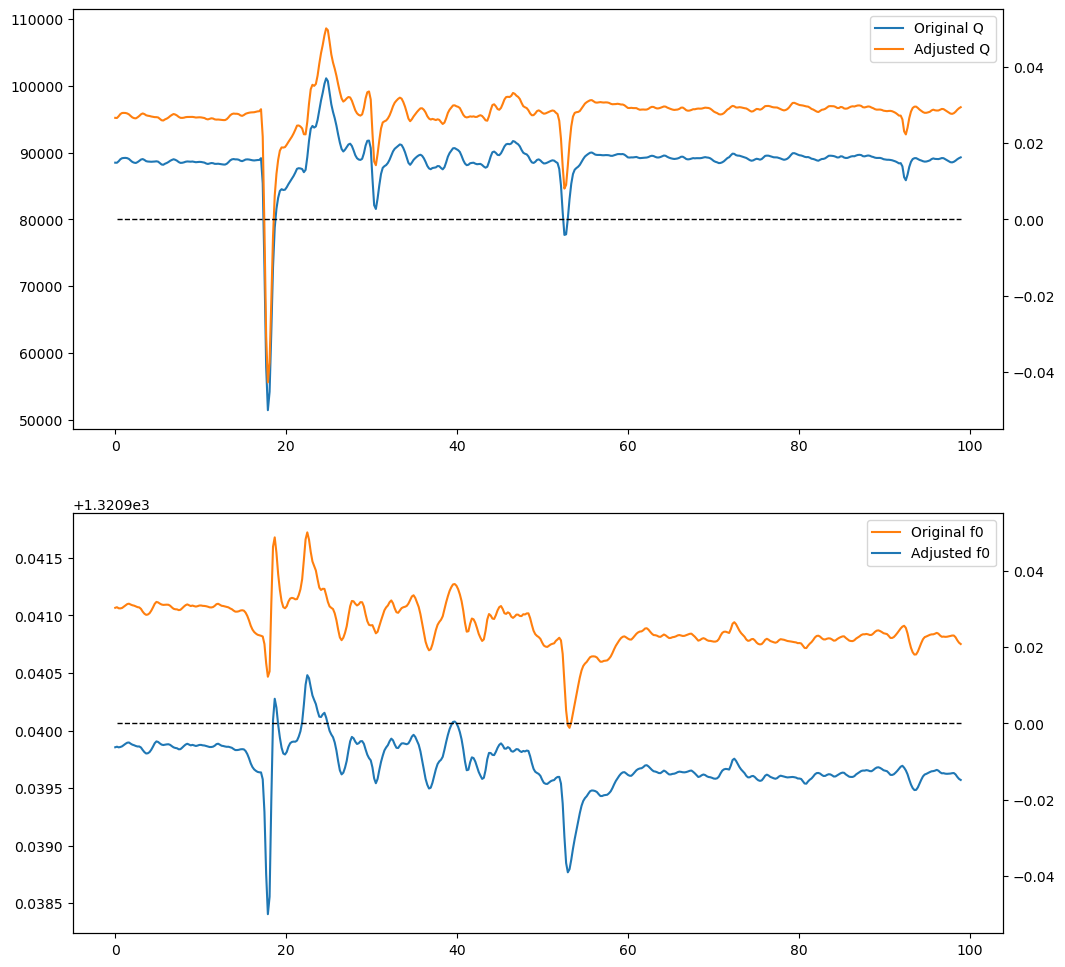